In [ ]:
import os
import sys
import json
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks

import seisbench.data as sbd
import seisbench.generate as sbg
import seisbench.models as sbm
from seisbench.util import worker_seeding

from tqdm import tqdm

In [ ]:
def set_seed(seed):
    """Set random seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def setup_device(device_type='cuda'):
    """Setup compute device."""
    if device_type == 'cuda' and torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')

class EarlyStopping:
    """Early stopping class to stop training when validation loss stops improving."""
    def __init__(self, patience=10, min_delta=0.0, checkpoint_dir='checkpoints/', verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.checkpoint_dir = Path(checkpoint_dir)
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.checkpoint_path = self.checkpoint_dir / 'best_model.pth'

    def __call__(self, val_loss, model, epoch):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(model, epoch)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(model, epoch)
            self.counter = 0

    def save_checkpoint(self, model, epoch):
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'best_score': self.best_score
        }, self.checkpoint_path)
        if self.verbose:
            print(f'Validation loss improved. Saving model to {self.checkpoint_path}')

def loss_fn(y_pred, y_true, eps=1e-8):
    """Custom Cross Entropy Loss matching SeisBench PhaseNet training."""
    h = y_true * torch.log(y_pred + eps)
    h = h.mean(-1).sum(-1)
    h = h.mean()
    return -h

def save_loss_history(history_dict, path):
    with open(path, "w") as f:
        json.dump(history_dict, f, indent=2)
    print(f"Loss history saved to {path}")

def save_final_model(model, config, path):
    torch.save({
        "model_state_dict": model.state_dict(),
        "config": config
    }, path)
    print(f"Final model saved to {path}")

In [ ]:
SEED = 42
set_seed(SEED)

In [ ]:
device = setup_device('cuda')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Load configuration
config_path = "icequake_train_config.json"
if not Path(config_path).exists():
    raise FileNotFoundError(f"Config file not found: {config_path}")

with open(config_path, "r") as f:
    config = json.load(f)
print(f"Loaded configuration from: {config_path}")

Loaded configuration from: icequake_train_config.json


In [ ]:
# Phase dictionary mapping metadata keys to string labels
phase_dict = {
    "trace_p_arrival_sample": "P",
    "trace_P_arrival_sample": "P",
    "trace_s_arrival_sample": "S",
    "trace_S_arrival_sample": "S",
}

In [ ]:
# Extract dataset and augmentation parameters
data_config = config.get("data", {})
dataset_name = data_config.get("dataset_name", "final_curated_seisbench_data")
sampling_rate = data_config.get("sampling_rate", 200)
window_len_large = data_config.get("windowlen_large", 2001)
window_len = data_config.get("window_len", 1001)
samples_before = data_config.get("samples_before", 1000)

In [ ]:
print("\nLoading dataset...")
data = sbd.WaveformDataset(dataset_name, sampling_rate=sampling_rate)
train, dev, test = data.train_dev_test()
print(f"Train: {len(train)}, Dev: {len(dev)}, Test: {len(test)}")

2026-04-24 23:12:47,535 | seisbench | WARNING | Component order not specified, defaulting to 'ZNE'.



Loading dataset...
Train: 259, Dev: 55, Test: 56


In [ ]:
# Data Generators
train_generator = sbg.GenericGenerator(train)
dev_generator = sbg.GenericGenerator(dev)
test_generator = sbg.GenericGenerator(test)

In [ ]:
# Augmentations tailored to our dataset size
# We use samples_before and window_len_large from config to center the trace loosely,
# then random window to the final window_len (e.g. 1001 samples)
augmentations = [
    sbg.WindowAroundSample(list(phase_dict.keys()), samples_before=samples_before, windowlen=window_len_large, selection="first", strategy="pad"),
    sbg.RandomWindow(windowlen=window_len, strategy="pad"),
    sbg.Normalize(demean_axis=-1, detrend_axis=-1, amp_norm_axis=-1, amp_norm_type="peak"),
    sbg.ChangeDtype(np.float32),
    sbg.ProbabilisticLabeller(sigma=int(sampling_rate * 0.15), dim=0),  # 0.15 sec sigma
]

In [ ]:
# Augmentations tailored to our dataset size
# We use samples_before and window_len_large from config to center the trace loosely,
# then random window to the final window_len (e.g. 1001 samples)
augmentations = [
    sbg.WindowAroundSample(list(phase_dict.keys()), samples_before=samples_before, windowlen=window_len_large, selection="first", strategy="pad"),
    sbg.RandomWindow(windowlen=window_len, strategy="pad"),
    sbg.Normalize(demean_axis=-1, detrend_axis=-1, amp_norm_axis=-1, amp_norm_type="peak"),
    sbg.ChangeDtype(np.float32),
    sbg.ProbabilisticLabeller(sigma=30, dim=0),  # 0.15 sec sigma
]

In [ ]:
train_generator.add_augmentations(augmentations)
dev_generator.add_augmentations(augmentations)
test_generator.add_augmentations(augmentations)

In [ ]:
# Dataloaders
train_config = config.get("training", {})
batch_size = train_config.get("batch_size", 4)
num_workers = train_config.get("num_workers", 2)
learning_rate = train_config.get("learning_rate", 0.01)
epochs = train_config.get("epochs", 50)
patience = train_config.get("patience", 5)

In [ ]:
train_loader = DataLoader(train_generator, batch_size=batch_size, shuffle=True, num_workers=num_workers, worker_init_fn=worker_seeding)
dev_loader = DataLoader(dev_generator, batch_size=batch_size, shuffle=False, num_workers=num_workers, worker_init_fn=worker_seeding)

In [ ]:
print("\nLoading PhaseNet model...")
model = sbm.PhaseNet()
model.to(device)


Loading PhaseNet model...


PhaseNet(
  (inc): Conv1d(3, 8, kernel_size=(7,), stride=(1,), padding=same)
  (in_bn): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (down_branch): ModuleList(
    (0): ModuleList(
      (0): Conv1d(8, 8, kernel_size=(7,), stride=(1,), padding=same, bias=False)
      (1): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): Conv1d(8, 8, kernel_size=(7,), stride=(4,), padding=(3,), bias=False)
      (3): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ModuleList(
      (0): Conv1d(8, 16, kernel_size=(7,), stride=(1,), padding=same, bias=False)
      (1): BatchNorm1d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): Conv1d(16, 16, kernel_size=(7,), stride=(4,), bias=False)
      (3): BatchNorm1d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (2): ModuleList(
      (0): Conv1d(16, 32, kernel_size=(7,), stride=(1,

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
# Setup checkpoints and history
checkpoint_dir = Path("checkpoints")
checkpoint_dir.mkdir(exist_ok=True)
best_model_path = checkpoint_dir / "best_model.pth"
final_model_path = checkpoint_dir / "final_model.pth"
history_path = checkpoint_dir / "loss_history.json"
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
plot_path = output_dir / "loss_history_plot.png"

In [ ]:
early_stopping = EarlyStopping(patience=patience, checkpoint_dir=checkpoint_dir, verbose=True)

In [ ]:
history = {"train_loss": [], "val_loss": []}

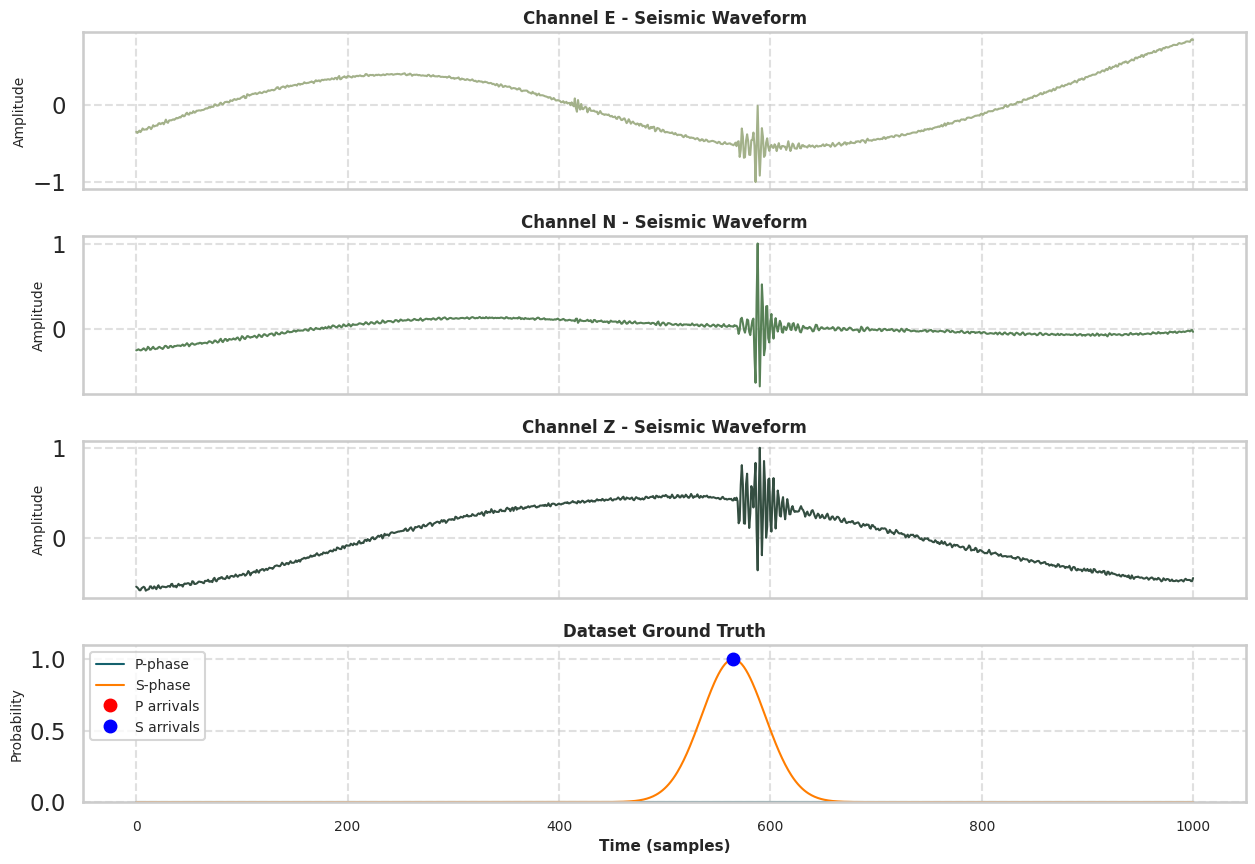

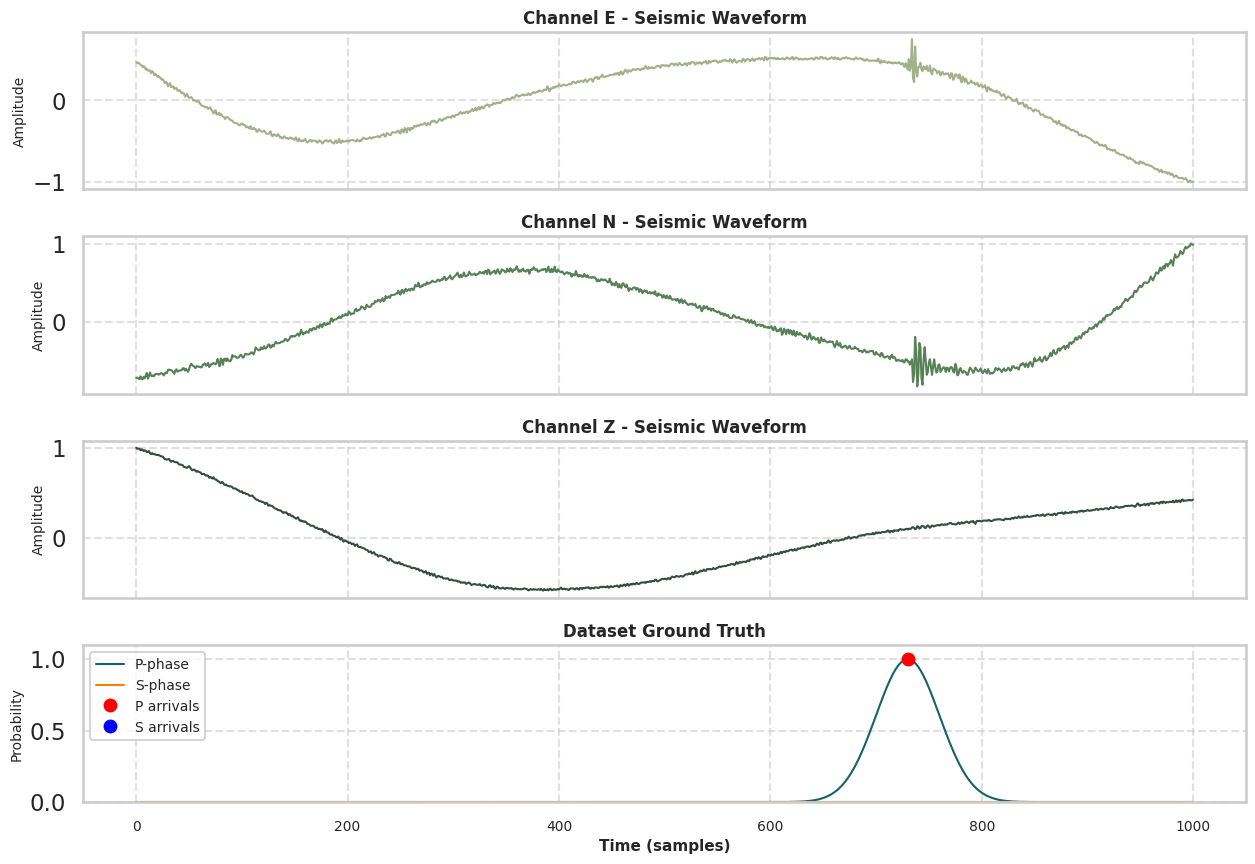

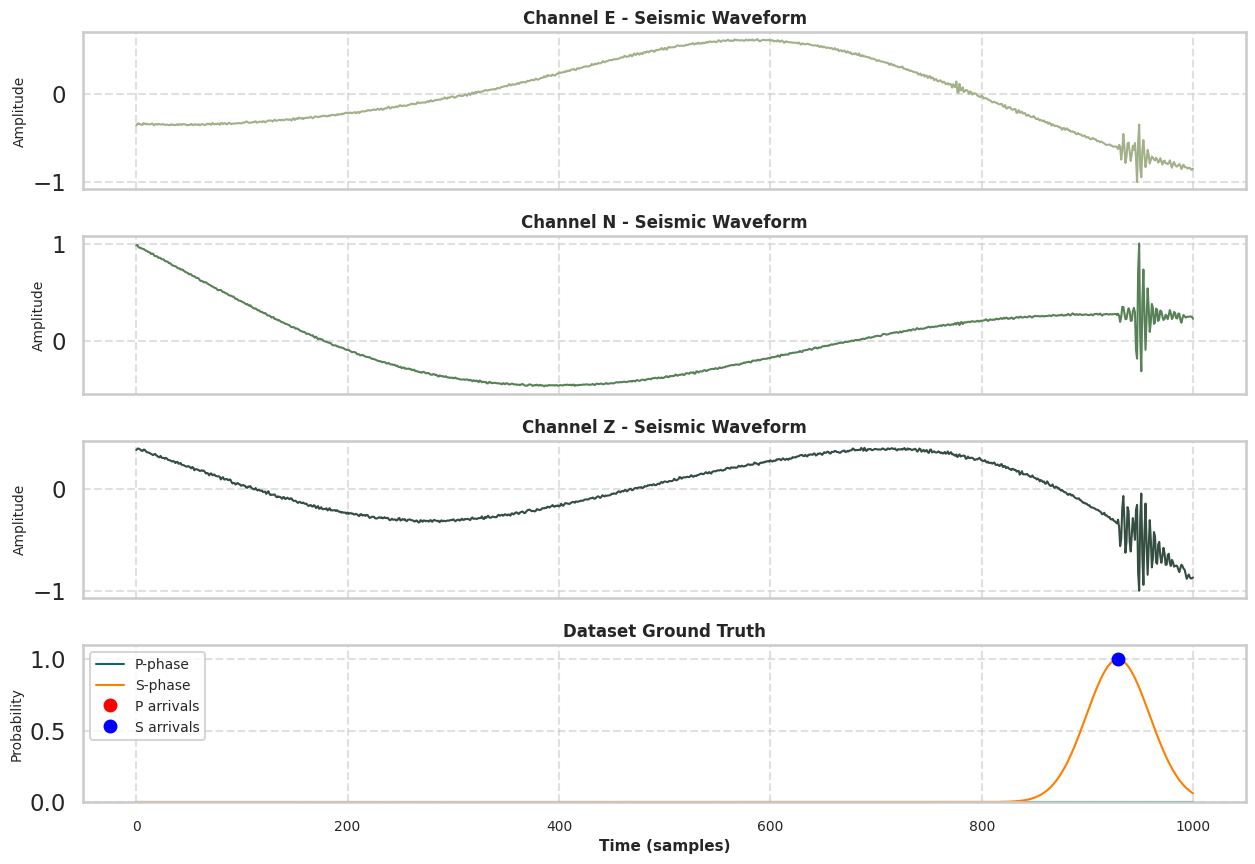

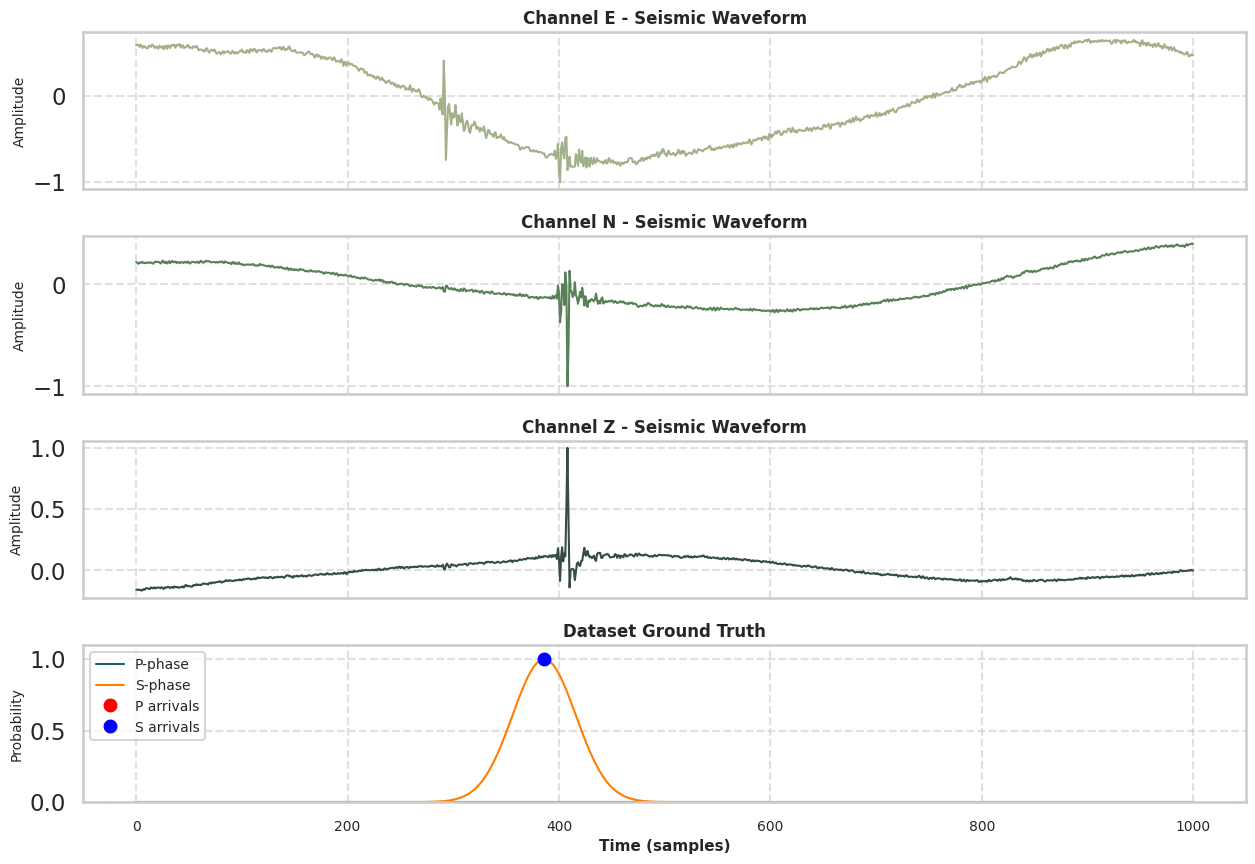

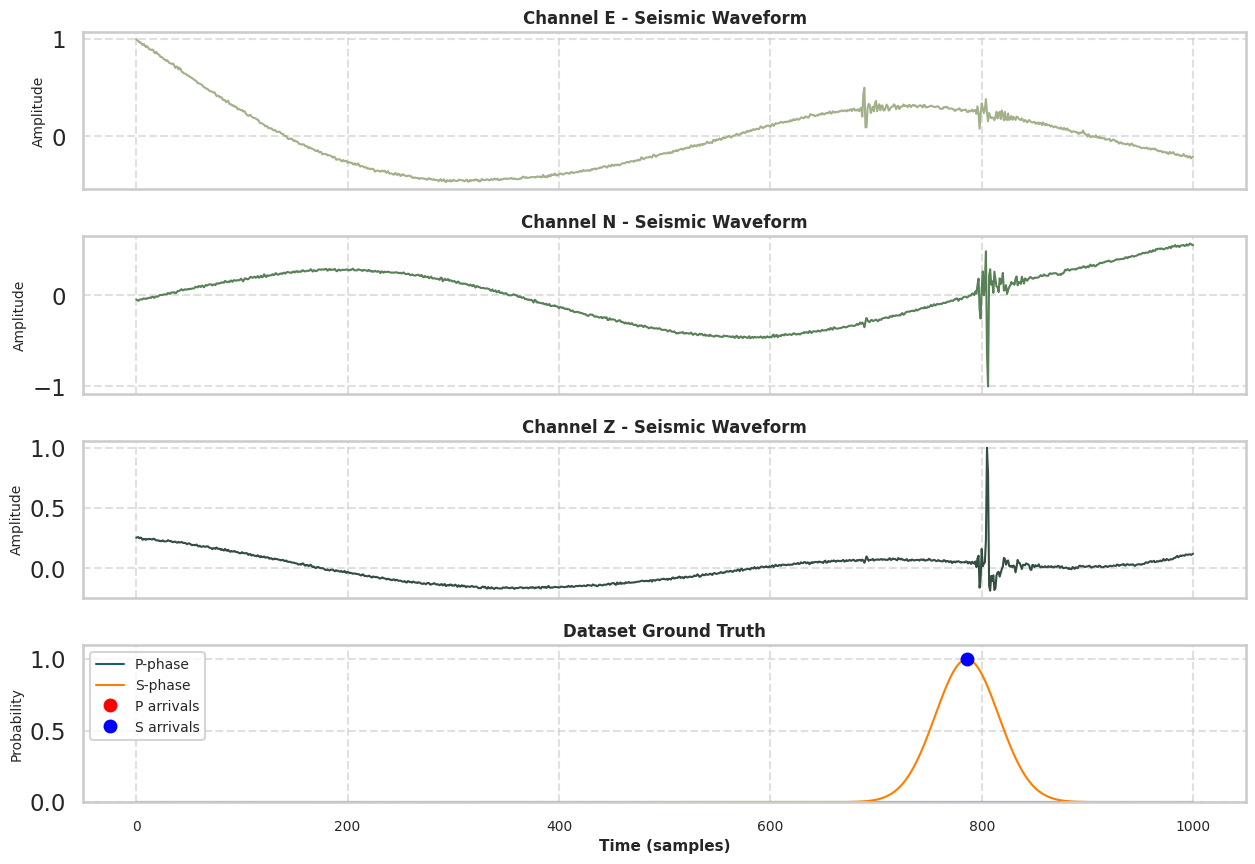

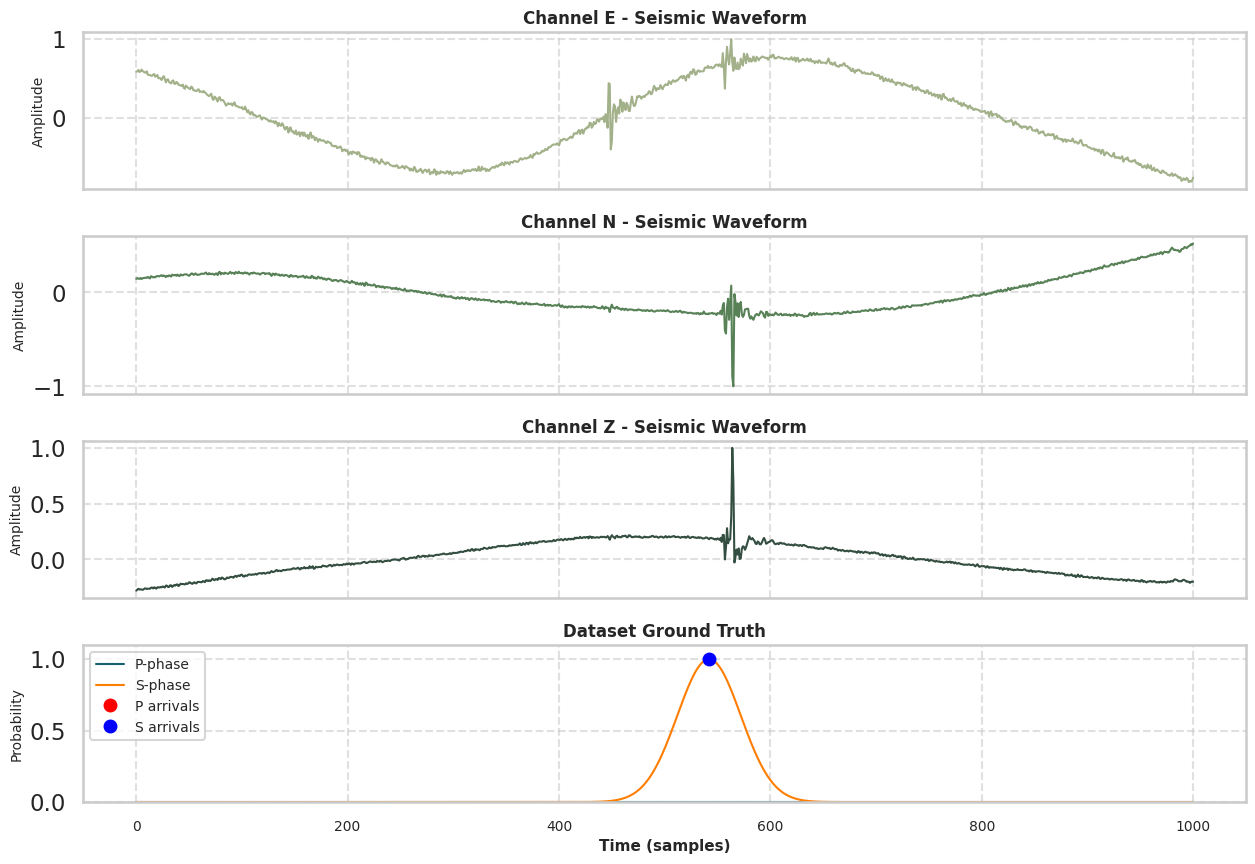

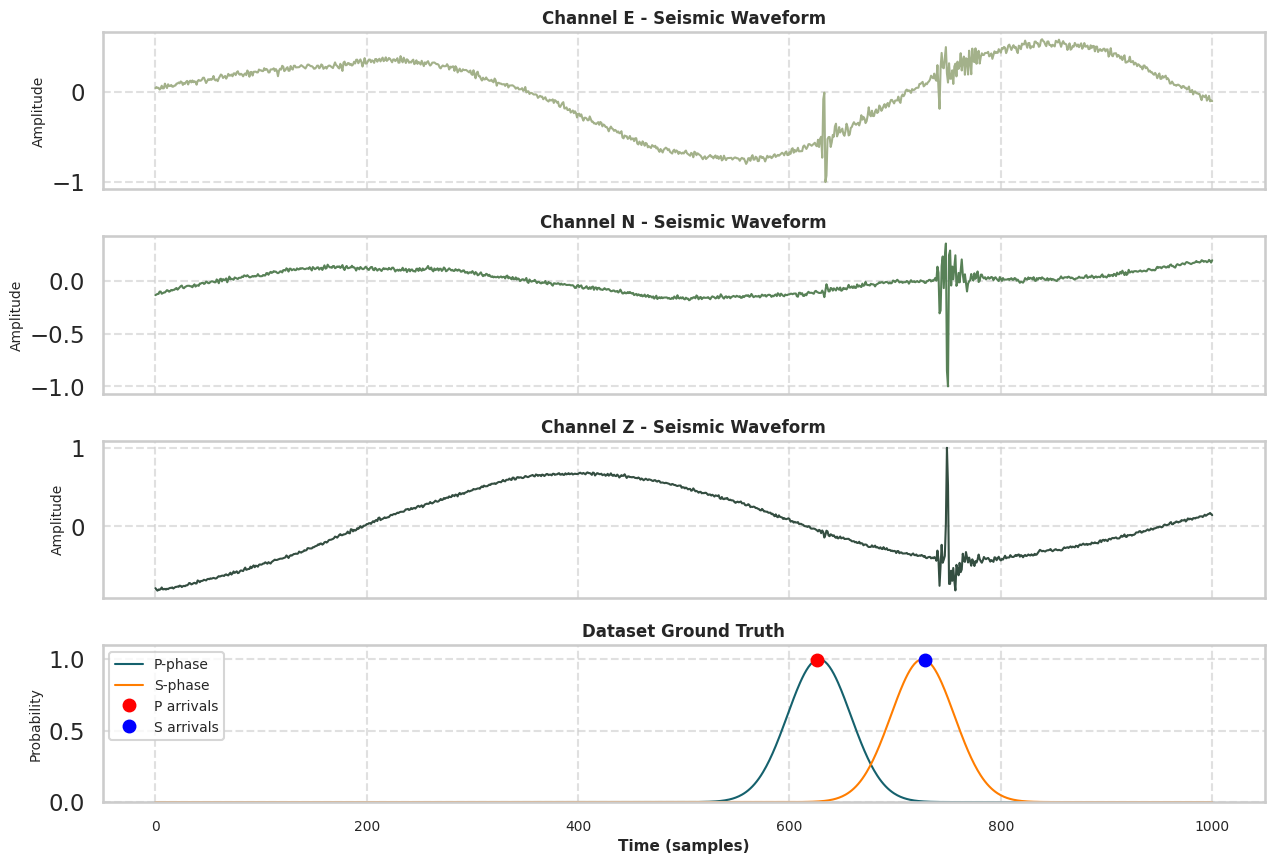

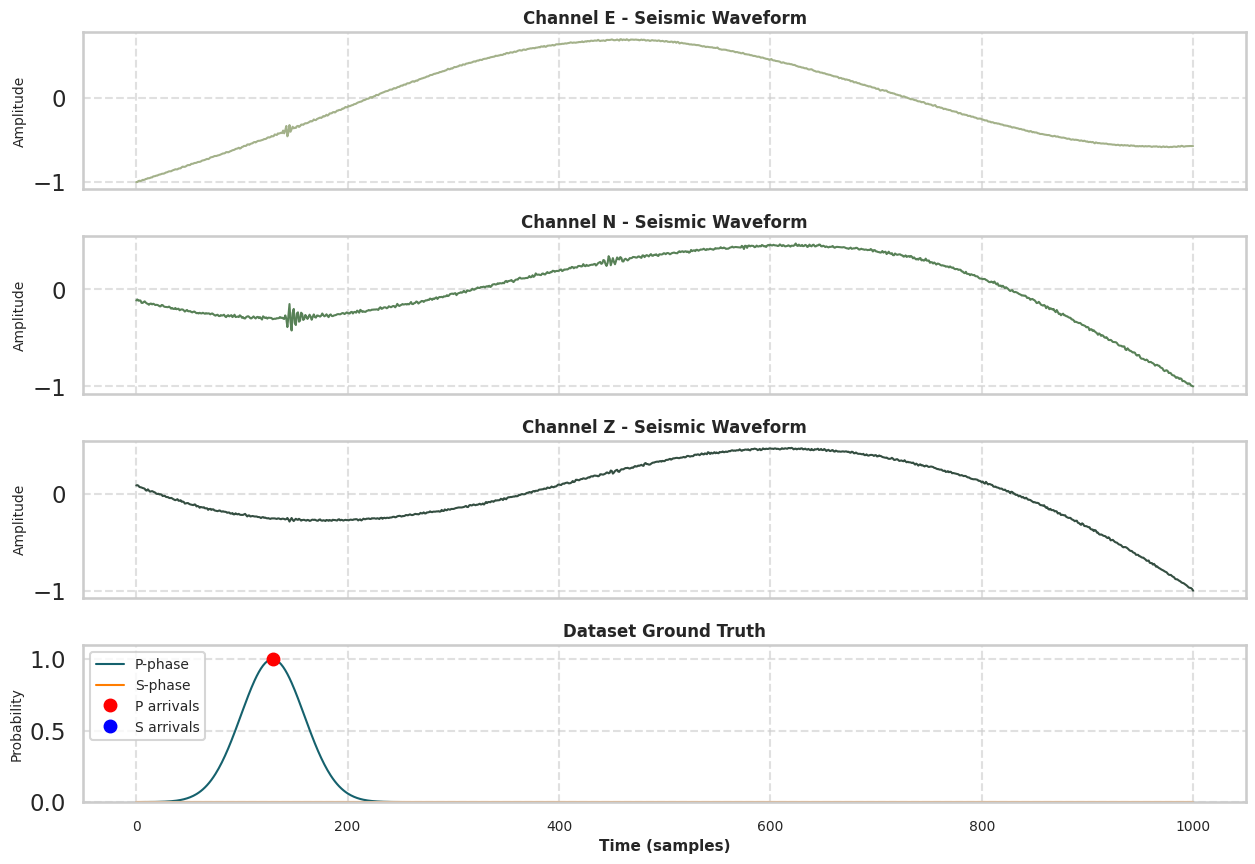

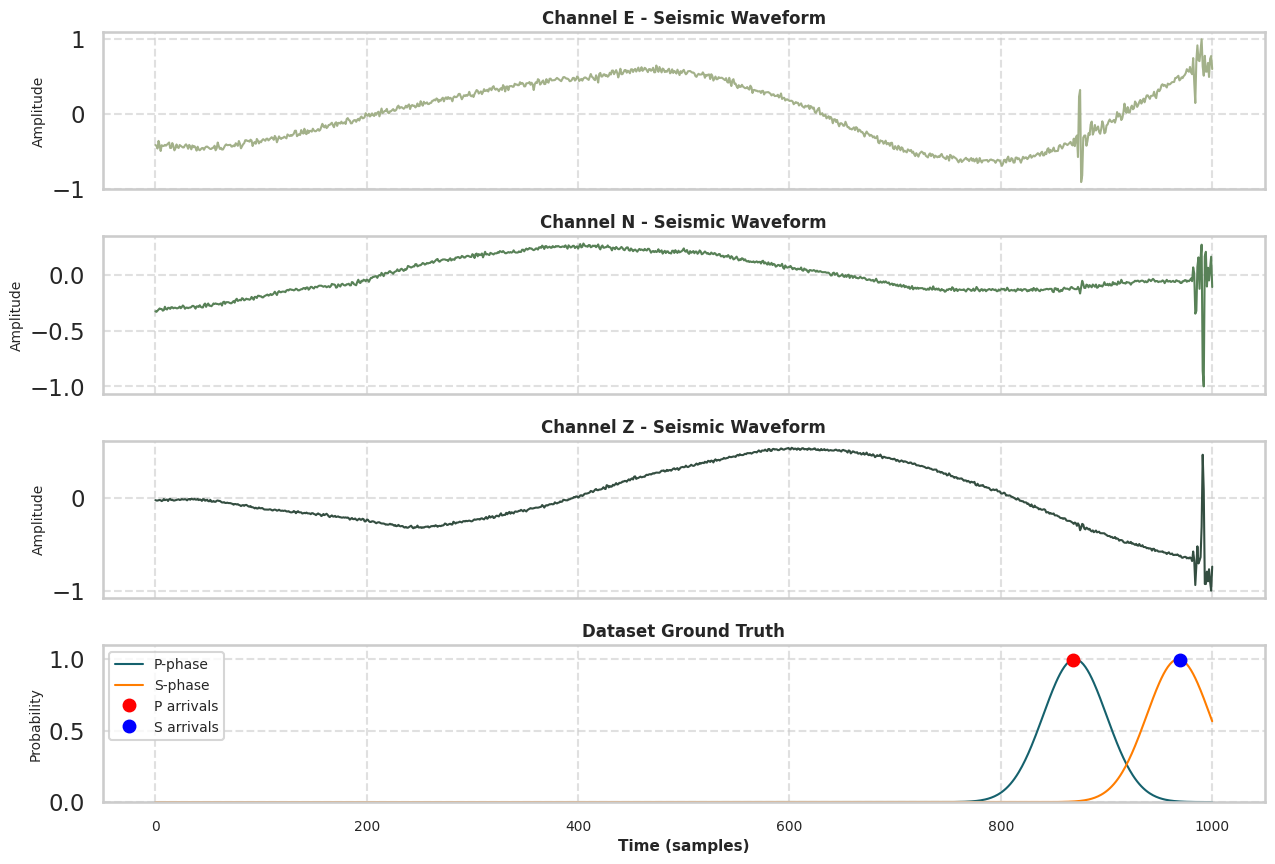

In [ ]:
# Run the prediction 4 times
for i in range(1, 10):
    # Visualizing Predictions
    sample = test_generator[np.random.randint(len(test_generator))]

    waveform = sample["X"]  # Shape: (3, N)
    labels = sample["y"]  # Shape: (3, N)

    time_axis = np.arange(waveform.shape[1])  # Create a time axis

    fig = plt.figure(figsize=(15, 10))
    axs = fig.subplots(4, 1, sharex=True, gridspec_kw={"hspace": 0.3})

    # Color setup
    channel_names = ["Channel E", "Channel N", "Channel Z"]
    waveform_colors = ['#a3b18a', '#588157', '#344e41']  # Custom colors for channels
    label_colors = ['#15616d', '#ff7d00']

    # Plot waveforms
    for j in range(3):
        axs[j].plot(time_axis, waveform[j], color=waveform_colors[j], linewidth=1.5)
        axs[j].set_title(f"{channel_names[j]} - Seismic Waveform", fontsize=12, fontweight='bold')
        axs[j].set_ylabel("Amplitude", fontsize=10)
        axs[j].grid(True, linestyle='--', alpha=0.6)

    # Find peaks in the ground truth labels
    y_p_peaks, _ = find_peaks(sample["y"][0], height=peak_height, distance=peak_distance)
    y_s_peaks, _ = find_peaks(sample["y"][1], height=peak_height, distance=peak_distance)

    # Convert ground truth peak indices to time values
    y_p_arrival_times = y_p_peaks / sampling_rate
    y_s_arrival_times = y_s_peaks / sampling_rate

    axs[3].plot(time_axis, labels[0], color=label_colors[0], linewidth=1.5, label="P-phase")
    axs[3].plot(time_axis, labels[1], color=label_colors[1], linewidth=1.5, label="S-phase")
    axs[3].plot(y_p_peaks, sample["y"][0, y_p_peaks], 'o', label='P arrivals', color='red')
    axs[3].plot(y_s_peaks, sample["y"][1, y_s_peaks], 'o', label='S arrivals', color='blue')
    axs[3].set_title("Dataset Ground Truth", fontsize=12, fontweight='bold')
    axs[3].set_ylim(0,1.1)
    axs[3].set_ylabel("Probability", fontsize=10)
    axs[3].grid(True, linestyle='--', alpha=0.6)
    axs[3].legend(fontsize=10, loc="upper left")
    
    # Improve x-axis visibility
    axs[3].set_xlabel("Time (samples)", fontsize=11, fontweight='bold')
    axs[3].tick_params(axis='x', labelsize=10)

    #plt.tight_layout()
    plot_filename = os.path.join(output_dir, f"Model_{i:03d}_Plot.png")
    plt.savefig(plot_filename)
    plt.show()
    #plt.close(fig)

    # Save the results to a text file
    results_filename = os.path.join(output_dir, f"Model_{i:03d}_Results.txt")
    with open(results_filename, "w") as f:
        f.write(f"Ground Truth P arrival times: {y_p_arrival_times}\n")
        f.write(f"Ground Truth S arrival times: {y_s_arrival_times}\n")

    # Save the parameters to a text file
    parameters_filename = os.path.join(output_dir, f"Model_{i:03d}_Parameters.txt")
    with open(parameters_filename, "w") as f:
        f.write(f"Data Sampling Rate: {sampling_rate}\n")
        f.write(f"Detection Height Parameter: {peak_height}\n")
        f.write(f"Detection Distance Parameter: {peak_distance}\n")


Starting Training...

Epoch 1/50


Validation: 100%|██████████| 14/14 [00:00<00:00, 71.98batch/s, loss=0.2017]


Train Loss: 0.4611 | Val Loss: 0.2200
Validation loss improved. Saving model to checkpoints/best_model.pth

Epoch 2/50


Validation: 100%|██████████| 14/14 [00:00<00:00, 80.15batch/s, loss=0.1315]


Train Loss: 0.1742 | Val Loss: 0.1472
Validation loss improved. Saving model to checkpoints/best_model.pth

Epoch 3/50


...

Train Loss: 0.1298 | Val Loss: 0.1289
EarlyStopping counter: 3/5

Epoch 15/50


Validation: 100%|██████████| 14/14 [00:00<00:00, 85.46batch/s, loss=0.1445]


Train Loss: 0.1225 | Val Loss: 0.1142
EarlyStopping counter: 4/5

Epoch 16/50


Validation: 100%|██████████| 14/14 [00:00<00:00, 95.87batch/s, loss=0.1265] 


Train Loss: 0.1186 | Val Loss: 0.1212
EarlyStopping counter: 5/5
Early stopping triggered at epoch 16
Final model saved to checkpoints/final_model.pth
Loss history saved to checkpoints/loss_history.json

Plotting Loss History...


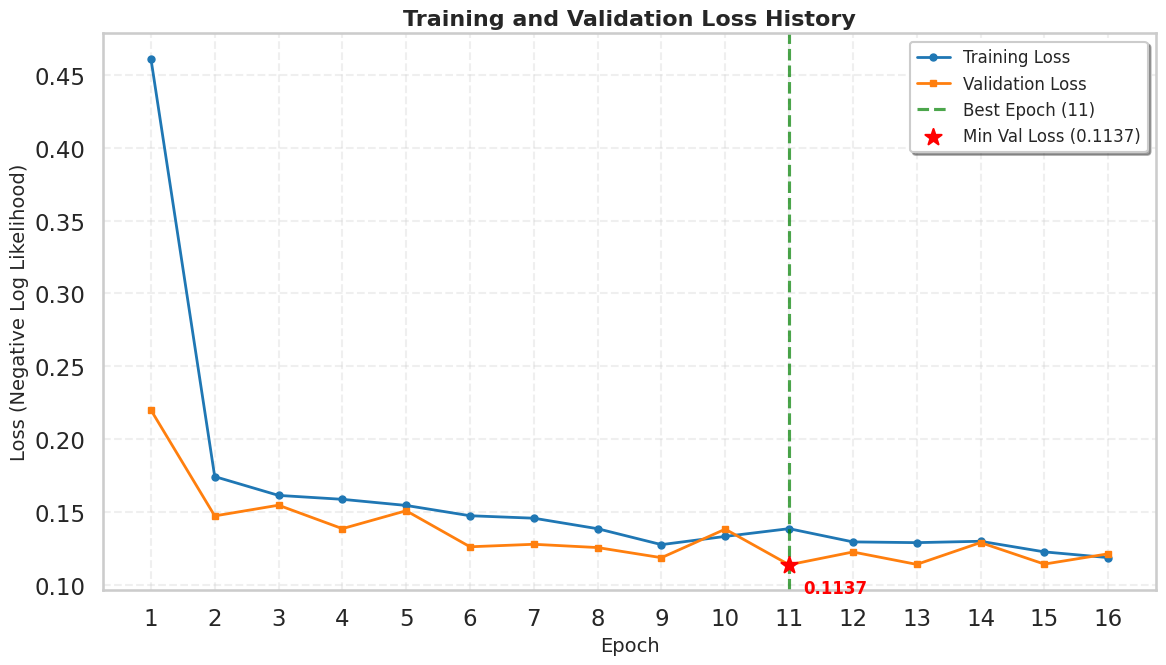

In [ ]:
print("\nStarting Training...")
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    print(f"\nEpoch {epoch+1}/{epochs}")
    train_pbar = tqdm(train_loader, desc="Training", unit="batch")
    
    for batch in train_pbar:
        pred = model(batch["X"].to(device))
        loss = loss_fn(pred, batch["y"].to(device))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_train_loss = train_loss / len(train_loader)
    history["train_loss"].append(avg_train_loss)

    model.eval()
    val_loss = 0.0
    
    val_pbar = tqdm(dev_loader, desc="Validation", unit="batch")
    with torch.no_grad():
        for batch in val_pbar:
            pred = model(batch["X"].to(device))
            loss = loss_fn(pred, batch["y"].to(device))
            val_loss += loss.item()
            val_pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_val_loss = val_loss / len(dev_loader)
    history["val_loss"].append(avg_val_loss)

    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    early_stopping(avg_val_loss, model, epoch)
    if early_stopping.early_stop:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

save_final_model(model, config, final_model_path)
save_loss_history(history, history_path)

print("\nPlotting Loss History...")
train_loss_data = history['train_loss']
val_loss_data = history['val_loss']
epochs_range = range(1, len(train_loss_data) + 1)

# Find best validation epoch
best_epoch_idx = np.argmin(val_loss_data)
best_epoch = best_epoch_idx + 1
best_val_loss = val_loss_data[best_epoch_idx]

plt.figure(figsize=(12, 7))
plt.plot(epochs_range, train_loss_data, label='Training Loss', marker='o', markersize=5, color='#1f77b4', linestyle='-', linewidth=2)
plt.plot(epochs_range, val_loss_data, label='Validation Loss', marker='s', markersize=5, color='#ff7f0e', linestyle='-', linewidth=2)

# Highlight best model
plt.axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
plt.scatter(best_epoch, best_val_loss, s=150, color='red', zorder=10, marker='*', label=f'Min Val Loss ({best_val_loss:.4f})')

plt.title('Training and Validation Loss History', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss (Negative Log Likelihood)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(fontsize=12, loc='best', frameon=True, shadow=True)
plt.xticks(epochs_range)

# Annotate values
plt.annotate(f'{best_val_loss:.4f}', 
             (best_epoch, best_val_loss), 
             xytext=(10, -20), 
             textcoords='offset points',
             fontsize=12,
             color='red',
             fontweight='bold')

plt.tight_layout()
plt.savefig(plot_path)
plt.show() # Skip inline showing for script unless requested


Generating Prediction Visualizations...
Evaluating Test Set Residuals...


Evaluating: 100%|██████████| 56/56 [00:00<00:00, 600.25sample/s]


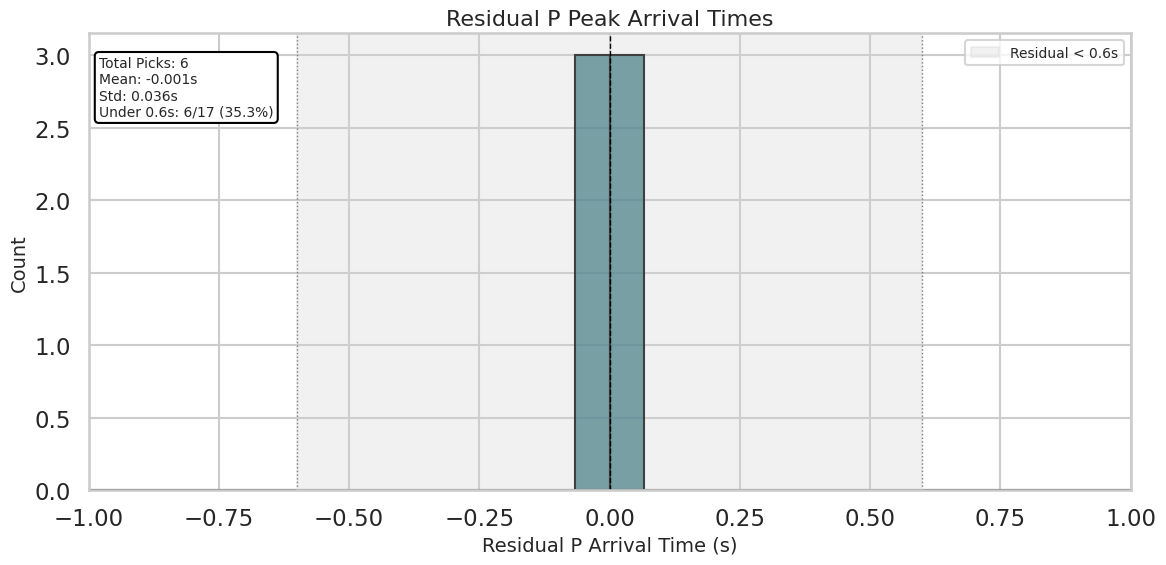

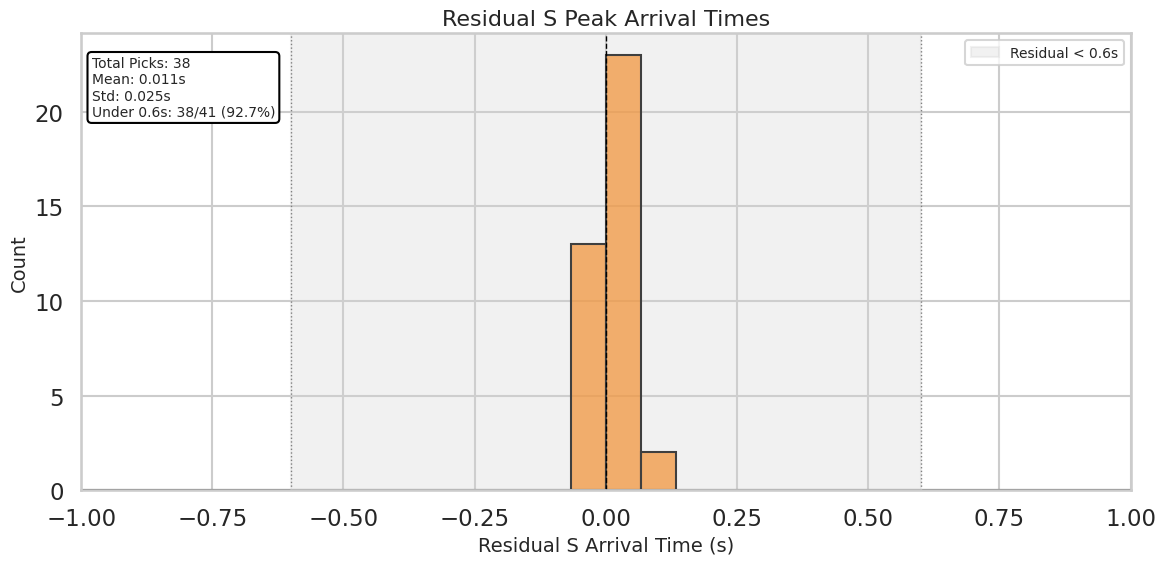


Training and Evaluation complete!


In [ ]:
# ==========================================
# Model Evaluation and Prediction Plotting
# ==========================================
print("\nGenerating Prediction Visualizations...")

# Load best model for evaluation
model.load_state_dict(torch.load(best_model_path)["model_state_dict"])
model.eval()

peak_config = config.get('peak_detection', {})
peak_height = peak_config.get('height', 0.5)
peak_distance = peak_config.get('distance', 100)

# Run the prediction 10 times for visualization
for i in range(1, 10):
    sample = test_generator[np.random.randint(len(test_generator))]
    waveform = sample["X"]  # Shape: (3, N)
    labels = sample["y"]    # Shape: (3, N)
    time_axis = np.arange(waveform.shape[1])
    
    fig = plt.figure(figsize=(15, 10))
    axs = fig.subplots(5, 1, sharex=True, gridspec_kw={"hspace": 0.3})
    
    channel_names = ["Channel E", "Channel N", "Channel Z"]
    waveform_colors = ['#a3b18a', '#588157', '#344e41']
    label_colors = ['#15616d', '#ff7d00']
    
    for j in range(3):
        axs[j].plot(time_axis, waveform[j], color=waveform_colors[j], linewidth=1.5)
        axs[j].set_title(f"{channel_names[j]} - Seismic Waveform", fontsize=12, fontweight='bold')
        axs[j].set_ylabel("Amplitude", fontsize=10)
        axs[j].grid(True, linestyle='--', alpha=0.6)
        
    y_p_peaks, _ = find_peaks(sample["y"][0], height=peak_height, distance=peak_distance)
    y_s_peaks, _ = find_peaks(sample["y"][1], height=peak_height, distance=peak_distance)
    
    y_p_arrival_times = y_p_peaks / sampling_rate
    y_s_arrival_times = y_s_peaks / sampling_rate
    
    axs[3].plot(time_axis, labels[0], color=label_colors[0], linewidth=1.5, label="P-phase")
    axs[3].plot(time_axis, labels[1], color=label_colors[1], linewidth=1.5, label="S-phase")
    axs[3].plot(y_p_peaks, sample["y"][0, y_p_peaks], 'o', label='P arrivals', color='red')
    axs[3].plot(y_s_peaks, sample["y"][1, y_s_peaks], 'o', label='S arrivals', color='blue')
    axs[3].set_title("Dataset Ground Truth", fontsize=12, fontweight='bold')
    axs[3].set_ylim(0, 1.1)
    axs[3].set_ylabel("Probability", fontsize=10)
    axs[3].grid(True, linestyle='--', alpha=0.6)
    axs[3].legend(fontsize=10, loc="upper left")
    
    with torch.no_grad():
        pred = model(torch.tensor(sample["X"], device=device).unsqueeze(0))
        pred = pred[0].cpu().numpy()
        
    p_prob = pred[0]
    s_prob = pred[1]
    
    p_peaks, _ = find_peaks(p_prob, height=peak_height, distance=peak_distance)
    s_peaks, _ = find_peaks(s_prob, height=peak_height, distance=peak_distance)
    
    axs[4].plot(p_prob, color=label_colors[0], linewidth=1.5, label='P-phase')
    axs[4].plot(p_peaks, p_prob[p_peaks], 'x', label='Detected P Arrival', color='red')
    axs[4].plot(s_prob, color=label_colors[1], linewidth=1.5, label='S-phase')
    axs[4].plot(s_peaks, s_prob[s_peaks], 'x', label='Detected S Arrival', color='blue')
    axs[4].set_title('Model Prediction', fontsize=12, fontweight='bold')
    axs[4].set_ylim(0, 1.1)
    axs[4].grid(True, linestyle='--', alpha=0.6)
    axs[4].set_ylabel('Probability', fontsize=10)
    axs[4].legend(fontsize=10, loc="upper left")
    axs[4].set_xlabel("Time (samples)", fontsize=11, fontweight='bold')
    axs[4].tick_params(axis='x', labelsize=10)
    
    plot_filename = output_dir / f"Model_Pred_{i:03d}_Plot.png"
    plt.savefig(plot_filename)
    plt.close(fig)
    
# ==========================================
# Residual Analysis
# ==========================================
print("Evaluating Test Set Residuals...")
all_residual_p_arrival_times = []
all_residual_s_arrival_times = []

groundtruth_p_peaks = 0
groundtruth_s_peaks = 0
count_residuals_p_under_0_6 = 0
count_residuals_s_under_0_6 = 0

for i in tqdm(range(len(test_generator)), desc="Evaluating", unit="sample"):
    sample = test_generator[i]
    
    y_p_peaks, _ = find_peaks(sample["y"][0], height=peak_height, distance=peak_distance)
    y_s_peaks, _ = find_peaks(sample["y"][1], height=peak_height, distance=peak_distance)
    
    groundtruth_p_peaks += len(y_p_peaks)
    groundtruth_s_peaks += len(y_s_peaks)
    
    y_p_arrival_times = y_p_peaks / sampling_rate
    y_s_arrival_times = y_s_peaks / sampling_rate
    
    with torch.no_grad():
        pred = model(torch.tensor(sample["X"], device=device).unsqueeze(0))
        pred = pred[0].cpu().numpy()
        
    p_prob, s_prob = pred[0], pred[1]
    p_peaks, _ = find_peaks(p_prob, height=peak_height, distance=peak_distance)
    s_peaks, _ = find_peaks(s_prob, height=peak_height, distance=peak_distance)
    
    p_arrival_times = p_peaks / sampling_rate
    s_arrival_times = s_peaks / sampling_rate
    
    for y_p_time in y_p_arrival_times:
        residual_p = p_arrival_times - y_p_time
        if len(residual_p) > 0:
            min_res_p = residual_p[np.argmin(np.abs(residual_p))]
            all_residual_p_arrival_times.append(min_res_p)
            if np.abs(min_res_p) < 0.6:
                count_residuals_p_under_0_6 += 1
                
    for y_s_time in y_s_arrival_times:
        residual_s = s_arrival_times - y_s_time
        if len(residual_s) > 0:
            min_res_s = residual_s[np.argmin(np.abs(residual_s))]
            all_residual_s_arrival_times.append(min_res_s)
            if np.abs(min_res_s) < 0.6:
                count_residuals_s_under_0_6 += 1

# Plot P Residuals
sns.set(style="whitegrid", context="talk")
x_min, x_max = -1, 1
bins = np.linspace(x_min, x_max, 31)

if len(all_residual_p_arrival_times) > 0:
    plt.figure(figsize=(12, 6))
    sns.histplot(all_residual_p_arrival_times, bins=bins, kde=False, color='#15616d', edgecolor='black', stat='count')
    plt.axvspan(-0.6, 0.6, color='#d3d3d3', alpha=0.3, label='Residual < 0.6s')
    plt.axvline(0, color='black', linestyle='--', linewidth=1)
    plt.axvline(-0.6, color='gray', linestyle=':', linewidth=1)
    plt.axvline(0.6, color='gray', linestyle=':', linewidth=1)
    
    mean_p = np.mean(all_residual_p_arrival_times)
    std_p = np.std(all_residual_p_arrival_times)
    fraction_p = count_residuals_p_under_0_6 / groundtruth_p_peaks if groundtruth_p_peaks > 0 else 0
    
    plt.text(x_min + 0.02, plt.gca().get_ylim()[1]*0.95,
             f'Total Picks: {len(all_residual_p_arrival_times)}\nMean: {mean_p:.3f}s\nStd: {std_p:.3f}s\nUnder 0.6s: {count_residuals_p_under_0_6}/{groundtruth_p_peaks} ({fraction_p:.1%})',
             ha='left', va='top', fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
    
    plt.title('Residual P Peak Arrival Times', fontsize=16)
    plt.xlabel('Residual P Arrival Time (s)', fontsize=14)
    plt.ylabel('Count', fontsize=14)
    plt.xlim(x_min, x_max)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(output_dir / "residual_p_histogram_shaded.png")
    plt.show()

# Plot S Residuals
if len(all_residual_s_arrival_times) > 0:
    plt.figure(figsize=(12, 6))
    sns.histplot(all_residual_s_arrival_times, bins=bins, kde=False, color='#ff7d00', edgecolor='black', stat='count')
    plt.axvspan(-0.6, 0.6, color='#d3d3d3', alpha=0.3, label='Residual < 0.6s')
    plt.axvline(0, color='black', linestyle='--', linewidth=1)
    plt.axvline(-0.6, color='gray', linestyle=':', linewidth=1)
    plt.axvline(0.6, color='gray', linestyle=':', linewidth=1)
    
    mean_s = np.mean(all_residual_s_arrival_times)
    std_s = np.std(all_residual_s_arrival_times)
    fraction_s = count_residuals_s_under_0_6 / groundtruth_s_peaks if groundtruth_s_peaks > 0 else 0
    
    plt.text(x_min + 0.02, plt.gca().get_ylim()[1]*0.95,
             f'Total Picks: {len(all_residual_s_arrival_times)}\nMean: {mean_s:.3f}s\nStd: {std_s:.3f}s\nUnder 0.6s: {count_residuals_s_under_0_6}/{groundtruth_s_peaks} ({fraction_s:.1%})',
             ha='left', va='top', fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
    
    plt.title('Residual S Peak Arrival Times', fontsize=16)
    plt.xlabel('Residual S Arrival Time (s)', fontsize=14)
    plt.ylabel('Count', fontsize=14)
    plt.xlim(x_min, x_max)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(output_dir / "residual_s_histogram_shaded.png")
    plt.show()

print("\nTraining and Evaluation complete!")